# Post-Stimulus Time Histogram (PSTH)
We will implement and visualize the Post-Stimulus Time Histogram (PSTH), a fundamental tool in neuroscience for analyzing neural responses to repeated stimuli. The PSTH provides a way to examine how spike activity evolves over time after a stimulus is presented.

In [114]:
# # Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# Import libraries
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.sparse import issparse

def plot_spike_train(peak_train, fs, ax):
    time_axis = np.arange(peak_train.size) / fs
    ax.plot(time_axis, peak_train, lw=.1, color='k', label='Spike')
    ax.set(xlabel='Time (s)', ylabel='Spike')
    ax.set_yticks([])
    ax.spines[['top', 'right']].set_visible(False)

## Load and plot the data
The dataset consists of two arrays:
*   `peak_train`: A sparse 1D NumPy array of shape (1, 3010000), representing a 300-second recording sampled at 10 kHz. Zeros indicate no spike activity, while values greater than zero indicate spike occurrences.
*   `artifact`: A 1D NumPy array containing the time indices of stimulus events within the recording.

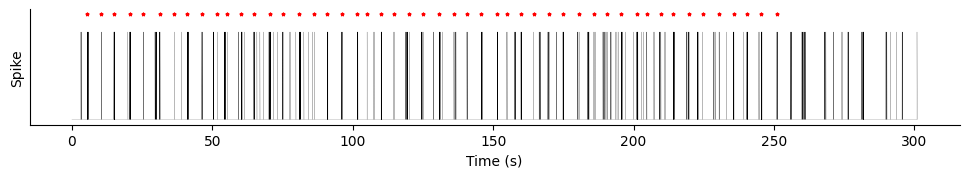

In [115]:
data = scipy.io.loadmat('./ptrain_620_DIV34_02_stim1_13_14.mat', squeeze_me=True)
sfreq = 10000

peak_train = data['peak_train']
stim = data['artifact']

# Ensure peak_train is a dense array
if issparse(peak_train):
    peak_train = peak_train.toarray().flatten()  # Convert to dense and flatten to 1D if necessary
else:
    peak_train = np.asarray(peak_train).flatten()

peak_train[peak_train > 0] = 1

fig, ax = plt.subplots(1, 1, figsize=(12, 1.5))
plot_spike_train(peak_train, sfreq, ax)

stimulus_times = np.where(stim > 0)[0]   # Get stimulus times in seconds
ax.scatter(stim/sfreq, np.ones_like(stimulus_times) * 1.2, color='r', marker='*', s=5, label='Stimulus')

## PSTH implementation
We will:
*   Compute the spike count in defined time bins after stimulus onset.
*   Normalize the histogram to obtain firing rates.
*   Visualize the neural response across trials.

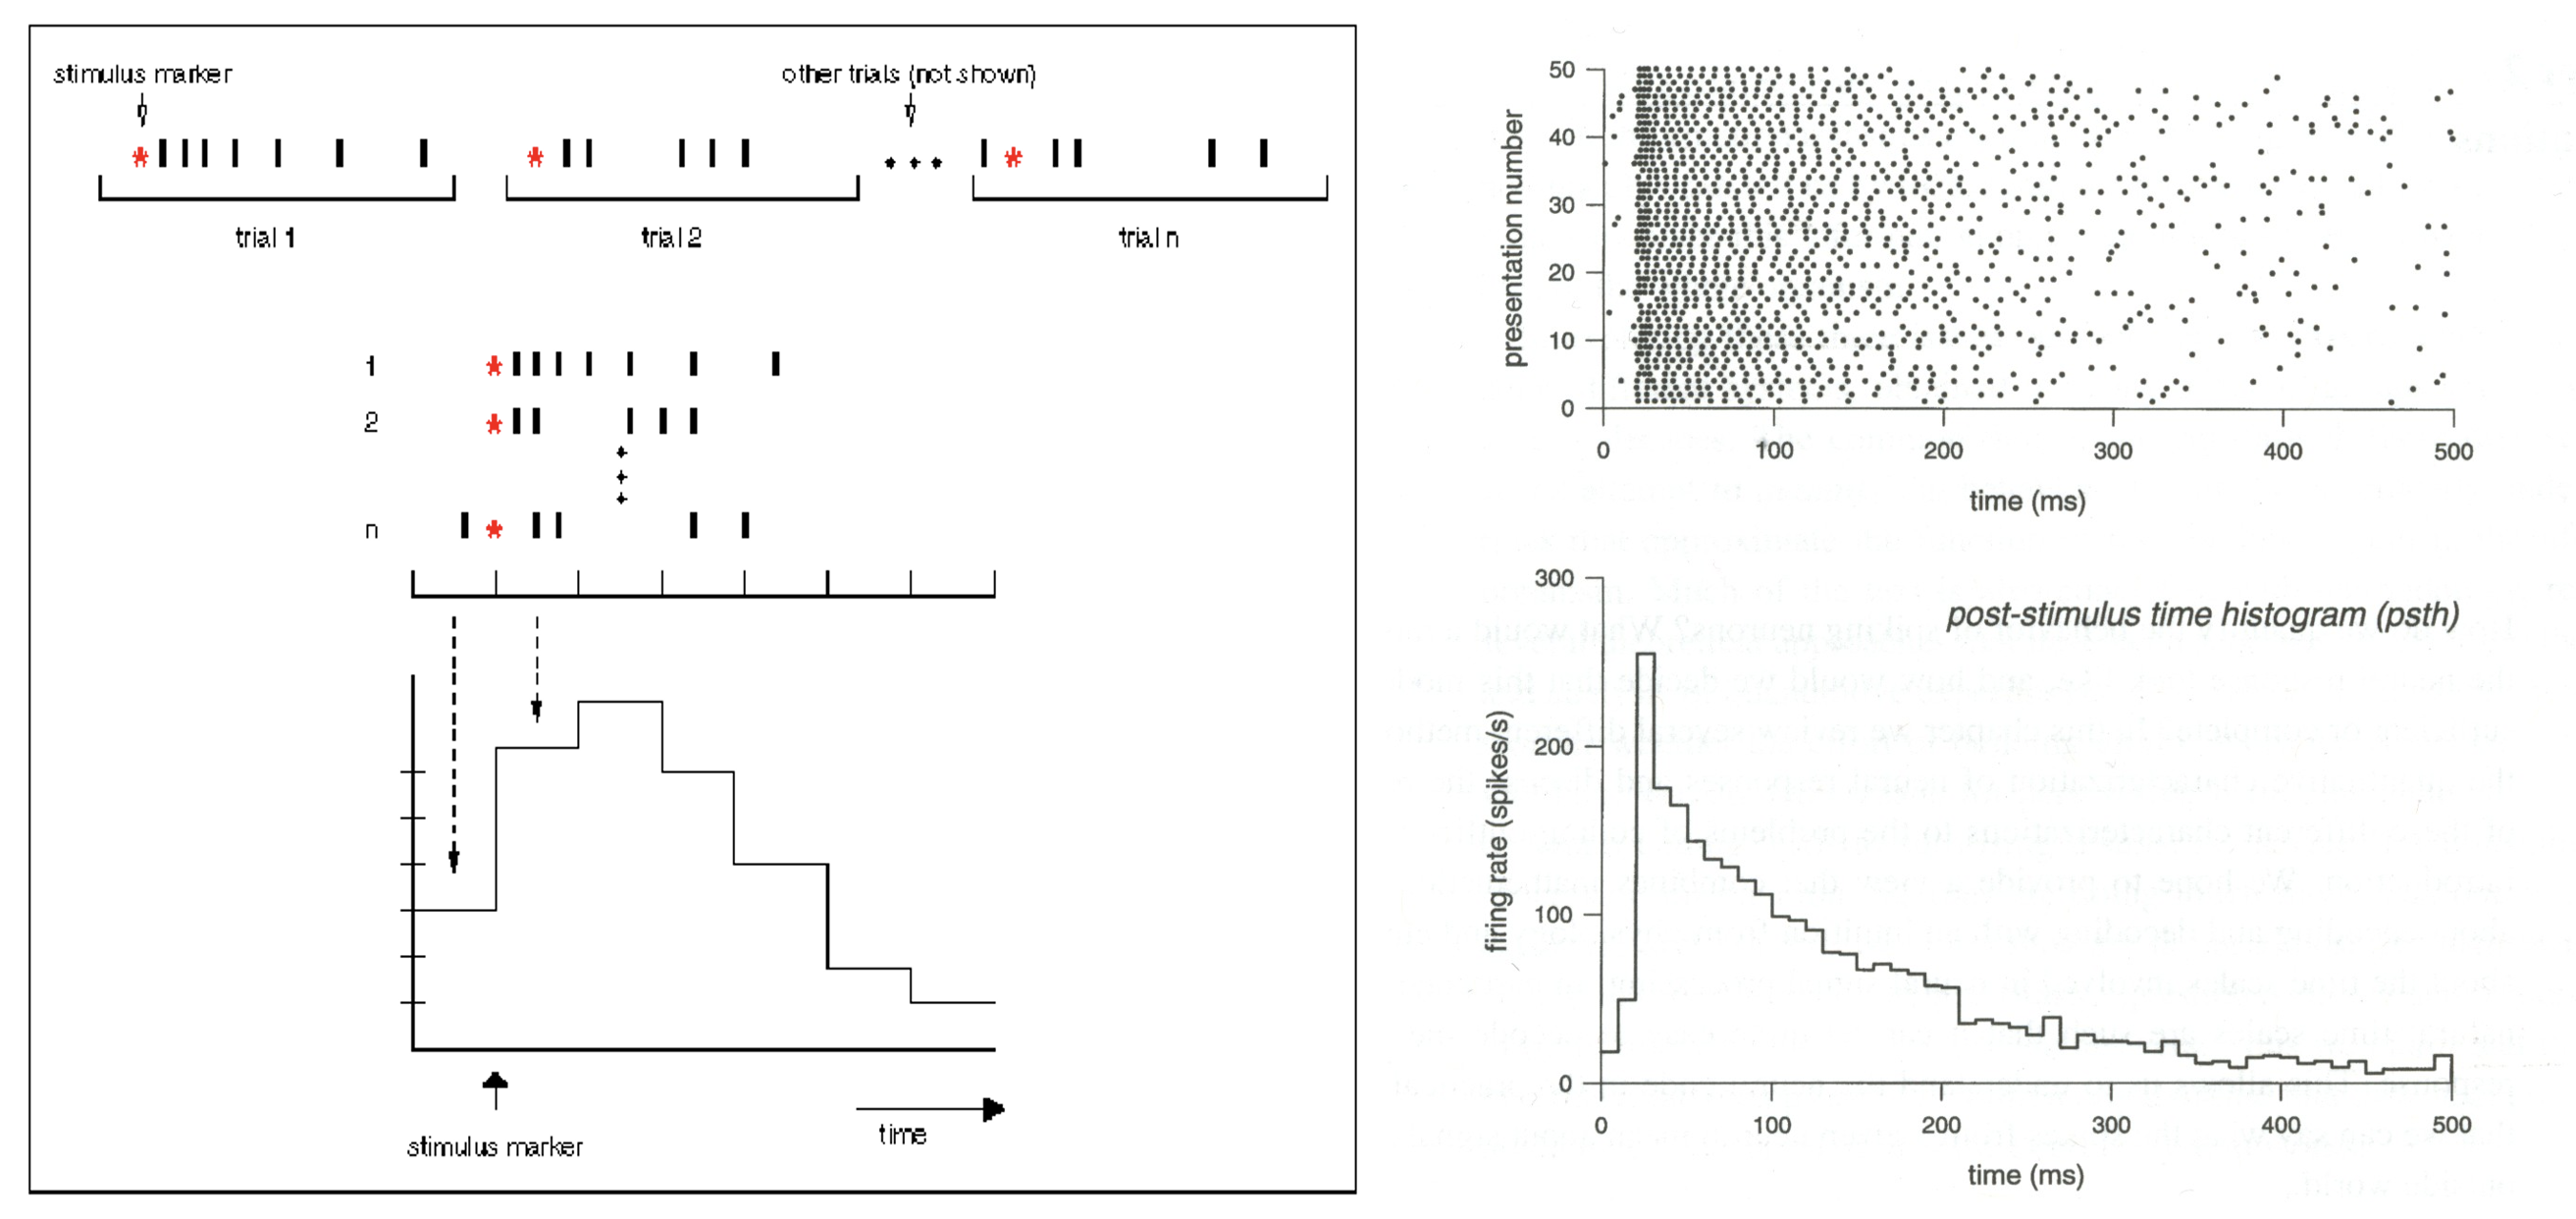

In [116]:
def compute_psth(peak_train, stimuli, wdw, binsize, sfreq):
    """
    Compute the Post-Stimulus Time Histogram (PSTH) for a given spike train and stimulus events.

    Parameters:
    - peak_train (ndarray): The binary spike train (1 for spikes, 0 for no spikes).
    - stimuli (ndarray): The indices of stimulus events.
    - wdw (float): The time window around each stimulus in seconds.
    - binsize (float): The size of each time bin in seconds.
    - sfreq (int): The sampling frequency in Hz (samples per second).

    Returns:
    - psth_out (ndarray): PSTH.
    """
    # Convert window size and bin size to samples
    wdw_samples = int(wdw * sfreq)
    binsize_samples = int(binsize * sfreq)

    trials = []

    for stim in stimuli:
        start_index = stim
        end_index = min(start_index + wdw_samples, peak_train.size)
        trial = np.array(peak_train[start_index:end_index])
        # Padding if necessary (if trial is shorter than window size)
        if len(trial) < wdw_samples:
            trial = np.pad(trial, (0, wdw_samples - len(trial)))
        else:
            trials.append(trial)
    cum_trials = np.sum(trials, axis=0)
    # Compute the histogram
    num_bins = int(np.ceil(wdw / binsize))
    psth_out = np.zeros(num_bins)
    for i in range(num_bins):
        bin_start = int(i * binsize_samples)
        bin_end = int((i + 1) * binsize_samples)
        # Count spikes in each bin
        psth_out[i] = np.sum(cum_trials[bin_start:bin_end])
    # Normalize by the number of trials
    num_trials = len(stimuli)
    if num_trials > 0:
        psth_out /= num_trials
        
    return psth_out

wdwsize = 0.5  # Window size in seconds
binsize = 0.002  # Bin size in seconds

psth = compute_psth(peak_train, stim, wdwsize, binsize, sfreq)

## Plot PSTH

24.920000000000005


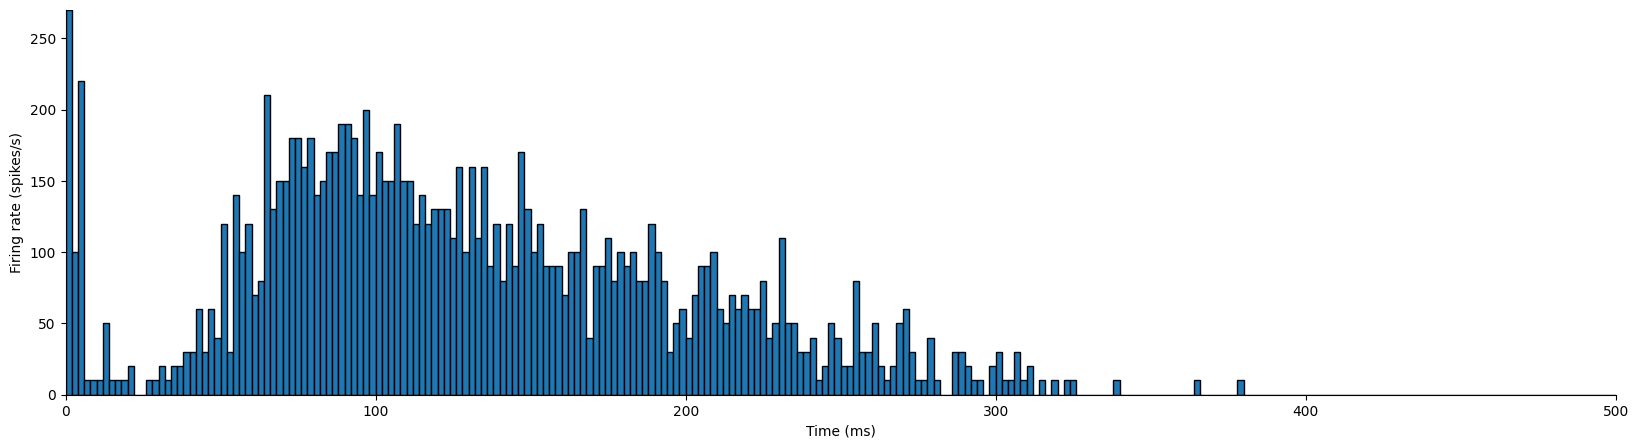

In [117]:
def plot_psth(count_peak_in_bin, binsize, wdwsize, ax, color=None):
    """
    Plot the Post-Stimulus Time Histogram (PSTH) from the spike counts in each bin.

    Parameters:
    - count_peak_in_bin (ndarray): Array containing the number of spikes in each bin.
    - binsize (float): The size of each time bin in seconds.
    - wdwsize (float): The total window size around the stimulus in seconds.

    This function plots the PSTH, with time on the x-axis and firing rate on the y-axis.
    """
    # Convert time to milliseconds for the x-axis
    time_axis = np.arange(count_peak_in_bin.size) * binsize * 1000  # time in ms
    
    # Compute firing rate in spikes per second
    firing_rate = count_peak_in_bin / binsize  # spikes per second
    
    # Plotting
    ax.bar(time_axis, firing_rate, width=binsize * 1000, color=color, align='edge', edgecolor='k')
    ax.set(xlabel='Time (ms)', ylabel='Firing rate (spikes/s)')
    ax.set_xlim([0, wdwsize * 1000])  # time window in ms
    ax.set_ylim([0, np.max(firing_rate)])  # adjust y-axis to fit firing rate
    ax.spines[['top', 'right']].set_visible(False)

# Plot PSTH
fig, ax = plt.subplots(1, 1, figsize=(20, 5))
plot_psth(psth, binsize, wdwsize, ax)
print(np.sum(psth))